In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("emmarex/plantdisease")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'plantdisease' dataset.
Path to dataset files: /kaggle/input/plantdisease


In [ ]:
!pip install tensorflow opencv-python matplotlib seaborn scikit-learn tensorboard

In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================

import os
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import confusion_matrix, classification_report

print("TensorFlow:", tf.__version__)

# ============================================================
# 2. CONFIG
# ============================================================

IMG_SIZE = 224
BATCH_SIZE = 16   # SAFE FOR COLAB
SEED = 123

data_dir = "/kaggle/input/plantdisease/PlantVillage"

os.makedirs("output_images", exist_ok=True)

# ============================================================
# 3. LOAD DATASET
# ============================================================

class_names = sorted([
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d))
])

print("Classes:", len(class_names))

full_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

# ============================================================
# 4. TRAIN / VAL SPLIT (SAFE)
# ============================================================

val_split = 0.1
val_batches = int(len(full_ds) * val_split)

val_ds = full_ds.take(val_batches)
train_ds = full_ds.skip(val_batches)

print("Train batches:", len(train_ds))
print("Val batches:", len(val_ds))

# ============================================================
# 5. PREPROCESS (NO CACHE -> NO CRASH)
# ============================================================

AUTOTUNE = tf.data.AUTOTUNE

def preprocess(x, y):
    x = tf.cast(x, tf.float32) / 255.0
    return x, y

train_ds = train_ds.map(preprocess, num_parallel_calls=AUTOTUNE)
val_ds = val_ds.map(preprocess, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

# ============================================================
# 6. MODEL (LIGHTWEIGHT MOBILE NET)
# ============================================================

base_model = tf.keras.applications.MobileNetV2(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

model = keras.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(len(class_names), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# ============================================================
# 7. TRAINING
# ============================================================

print("\n--- Training Started ---")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# ============================================================
# 8. FINE TUNING
# ============================================================

print("\n--- Fine Tuning ---")

base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    initial_epoch=history.epoch[-1]
)

# ============================================================
# 9. SAVE MODEL
# ============================================================

model.save("plant_disease_model.keras")
print("Model Saved!")

# ============================================================
# 10. EVALUATION
# ============================================================

y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 10))
sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.savefig("output_images/confusion_matrix.png")
plt.close()

# ============================================================
# 12. ACCURACY GRAPH
# ============================================================

plt.figure()
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["train", "val"])
plt.savefig("output_images/accuracy.png")
plt.close()

# ============================================================
# 13. LOSS GRAPH
# ============================================================

plt.figure()
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["train", "val"])
plt.savefig("output_images/loss.png")
plt.close()

# ============================================================
# 14. FINAL OUTPUT
# ============================================================

print("\n===================================")
print("TRAINING COMPLETE")
print("===================================")

print("Model saved: plant_disease_model.keras")
print("Graphs saved in output_images/")

TensorFlow: 2.20.0
Classes: 15
Found 20638 files belonging to 15 classes.
Train batches: 1161
Val batches: 129
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         1,935 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,887 (9.25 MB)

 Trainable params: 165,903 (648.06 KB)

 Non-trainable params: 2,257,984 (8.61 MB)


--- Training Started ---
Epoch 1/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 108s 71ms/step - accuracy: 0.7317 - loss: 0.8275 - val_accuracy: 0.8609 - val_loss: 0.4184
Epoch 2/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.8302 - loss: 0.5031 - val_accuracy: 0.8929 - val_loss: 0.3310
Epoch 3/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 31s 25ms/step - accuracy: 0.8477 - loss: 0.4428 - val_accuracy: 0.9079 - val_loss: 0.2854
Epoch 4/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 33s 26ms/step - accuracy: 0.8687 - loss: 0.3868 - val_accuracy: 0.9012 - val_loss: 0.2973
Epoch 5/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.8694 - loss: 0.3760 - val_accuracy: 0.9079 - val_loss: 0.2662
Epoch 6/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.8732 - loss: 0.3618 - val_accuracy: 0.9138 - val_loss: 0.2555
Epoch 7/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 34s 27ms/step - accuracy: 0.8774 - loss: 0.3445 - val_accuracy: 0.9104 - val_loss: 0.2632
Epoch 8/10
1161/1161 ━━━━━━━━━━━━━━━━━━━━ 32s 26m

In [ ]:
y_true = []
y_pred = []

for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

from sklearn.metrics import classification_report
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98        90
           1       0.99      1.00      1.00       141
           2       0.97      0.99      0.98        91
           3       1.00      0.95      0.97        94
           4       0.87      0.93      0.90        14
           5       0.94      0.99      0.96       224
           6       0.95      0.71      0.81       101
           7       0.96      0.95      0.95       183
           8       0.92      0.90      0.91       105
           9       0.87      0.95      0.91       167
          10       0.92      0.89      0.91       187
          11       0.86      0.88      0.87       144
          12       0.99      0.98      0.98       315
          13       0.94      0.98      0.96        50
          14       0.95      0.97      0.96       158

    accuracy                           0.94      2064
   macro avg       0.94      0.94      0.94      2064
weighted avg       0.94   

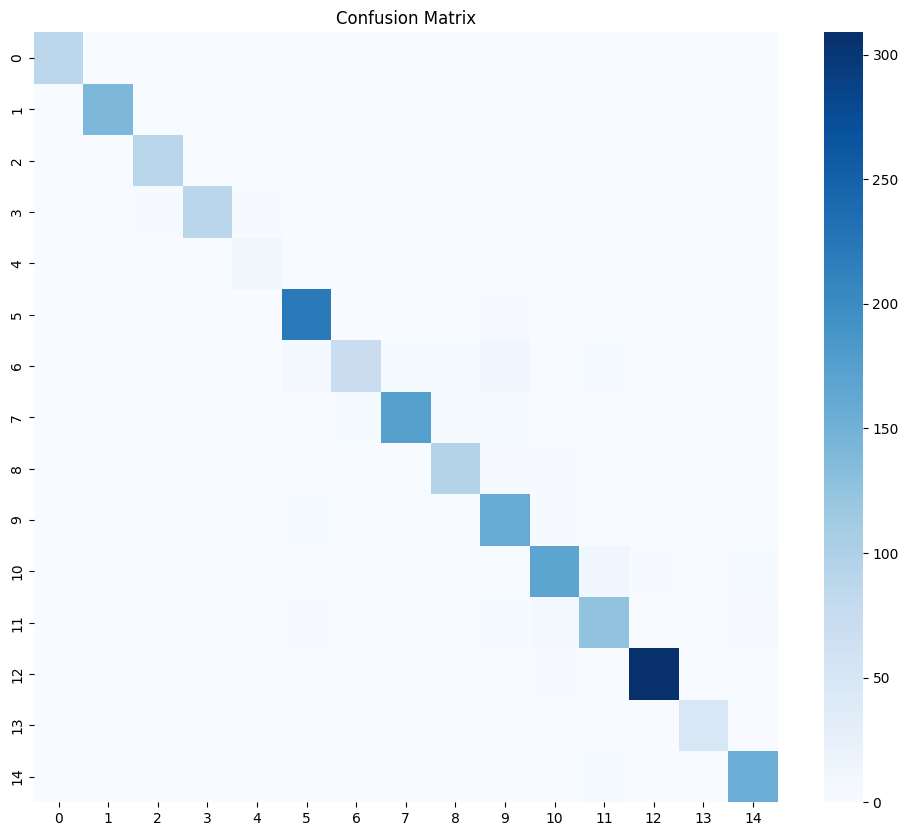

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


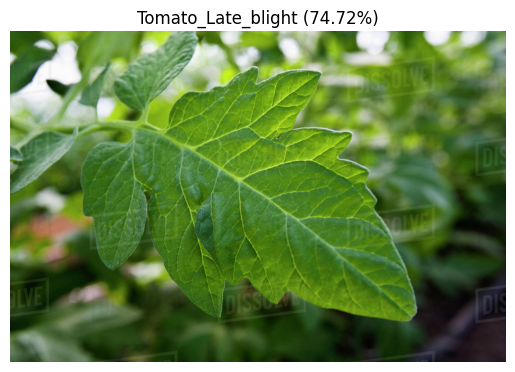

In [ ]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt

# 1. Model Load
model = tf.keras.models.load_model("plant_disease_model.keras")

# 2. EXACT Class Names (As per your report)
class_names = [
    "Pepper__bell___Bacterial_spot",
    "Pepper__bell___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Tomato_Bacterial_spot",
    "Tomato_Early_blight",
    "Tomato_Late_blight",
    "Tomato_Leaf_Mold",
    "Tomato_Septoria_leaf_spot",
    "Tomato_Spider_mites_Two_spotted_spider_mite",
    "Tomato__Target_Spot",
    "Tomato__Tomato_YellowLeaf__Curl_Virus",
    "Tomato__Tomato_mosaic_virus",
    "Tomato_healthy"
]

def predict_it(img_path):
    IMG_SIZE = 224 # Check karlein agar aapne 128 ya kuch aur rakha tha training mein

    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Preprocessing
    resized = cv2.resize(img_rgb, (IMG_SIZE, IMG_SIZE))
    normalized = resized / 255.0
    input_data = np.expand_dims(normalized, axis=0)

    # Predict
    prediction = model.predict(input_data)
    result_index = np.argmax(prediction)
    confidence = np.max(prediction) * 100

    # Display
    plt.imshow(img_rgb)
    plt.title(f"{class_names[result_index]} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

# Image path yahan dein
predict_it("/content/heallthy.jpg")